In [1]:
import numpy as np                
import pandas as pd              
import matplotlib.pyplot as plt  
import yfinance as yf            


In [2]:
file_path = "D:/Webpage/MONTE CARLO/PriceHistory NVDIA.xlsx"
df = pd.read_excel(file_path, sheet_name='Price History', skiprows=2)
df = df.rename(columns={'Date': 'Date', 'Price': 'Adj Close'})
df = df[['Date', 'Adj Close']]
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)


In [3]:
df['Daily Return'] = df['Adj Close'].pct_change()


In [4]:
mu = df['Daily Return'].mean() * 252
sigma = df['Daily Return'].std() * np.sqrt(252)
print(f"mu (expected return): {mu:.2%}")
print(f"sigma (volatility): {sigma:.2%}")


mu (expected return): 35.90%
sigma (volatility): 49.96%


In [5]:
S0 = df['Adj Close'].iloc[-1]
T = 1                     
steps = 252               
simulations = 1000         
dt = T / steps            

In [6]:
price_paths = np.zeros((steps, simulations)) 
price_paths[0] = S0                           


In [7]:
for sim in range(simulations):
    for t in range(1, steps):
        z = np.random.normal()   
        drift = (mu - 0.5 * sigma**2) * dt   
        shock = sigma * np.sqrt(dt) * z     
        price_paths[t, sim] = price_paths[t-1, sim] * np.exp(drift + shock)


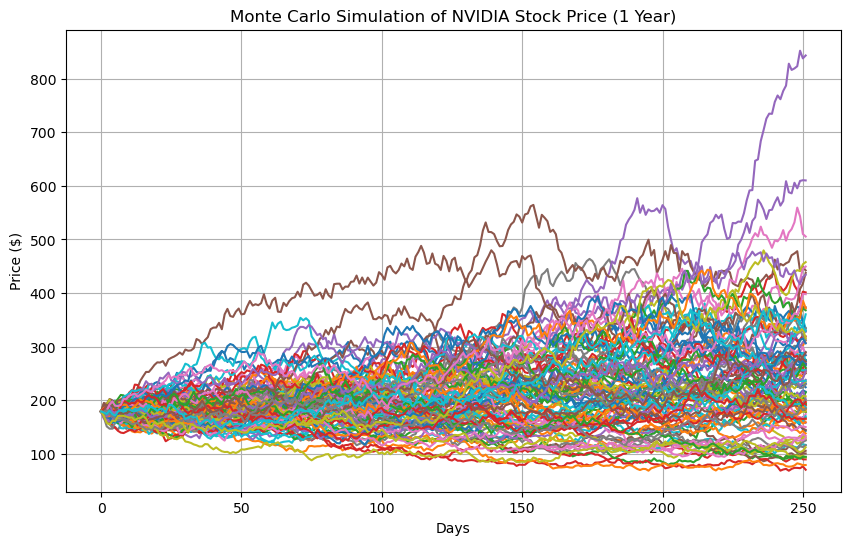

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(price_paths[:, :100])
plt.title("Monte Carlo Simulation of NVIDIA Stock Price (1 Year)")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.grid(True)
plt.show()


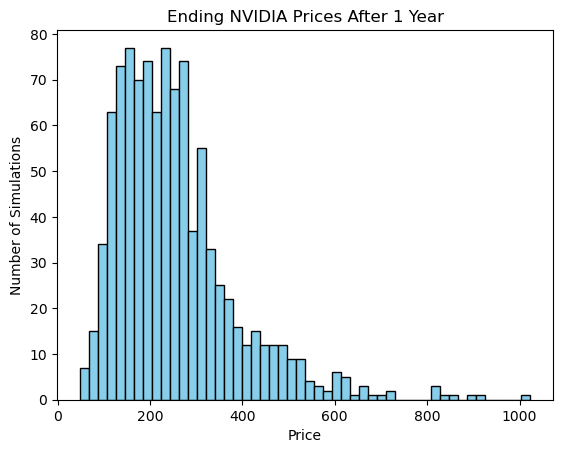

Expected Price: $252.65
Median Price: $229.22
Chance of Gain: 67.80%


In [9]:
final_prices = price_paths[-1]

plt.hist(final_prices, bins=50, color="skyblue", edgecolor="black")
plt.title("Ending NVIDIA Prices After 1 Year")
plt.xlabel("Price")
plt.ylabel("Number of Simulations")
plt.show()

print(f"Expected Price: ${np.mean(final_prices):.2f}")
print(f"Median Price: ${np.median(final_prices):.2f}")
print(f"Chance of Gain: {(np.mean(final_prices > S0) * 100):.2f}%")
